Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.


# Solución de la ecuación de calor usando un esquema explícito

Queremos resolver la ecuación

$$\frac{\partial u}{\partial t} = \alpha\nabla^2 u + q \quad \forall x\in(-1, 1)\, , \forall t \in (0, t_\max)$$

con $u(-1, t) = u_a$ y $u(1, t)=u_b$ como condiciones de frontera. Adicionalmente, tenemos
la siguiente condición inicial

$$u(x, 0) = u_0(x)\, .$$

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib widget

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from diferencias import resolver_explicito

In [4]:
# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

## Simulación

A continuación definimos los parámetros para la simulación.
Note que se puede cambiar la difusividad térmica ($\alpha$).

In [5]:
niter = 10000
nx = 200
alpha = 1.0
fuente = lambda x: np.sin(4*x)

x = np.linspace(-1, 1, nx)
np.random.seed(201)
u_ini = 0.5 * (1 + x) + 1 * np.random.normal(size=nx)
u_a = 0.0
u_b = 1.0
u_ini[0] = u_a
u_ini[-1] = u_b
k_iter = 0.4
dx = x[1] - x[0]
dt = k_iter * dx**2/alpha
t = np.linspace(0, niter*dt, niter)

La siguiente celda calcula la solución del problema
para la malla y el número de instantes definidos.

<div class="alert-info">
<b> Estabilidad de la simulación </b>

Como discutimos en clase, el número de Fourier de la malla
debe ser menor a 0.5 para que la simulación sea estable.
Pruebe a cambiar ``k_iter``.
</div>

In [6]:
U = resolver_explicito(niter, u_ini, alpha, dt, x, fuente)

## Animación

Podemos animar la solución para ver la evolución del sistema.

Sin embargo, también es buena idea verificar si la solución converge
a la solución estacionaria que está dada por

$$ u_\text{est}(x) = \frac{u_{a}(1 - x)}{2} + \frac{u_{b}(1 + x)}{2} - \frac{\sin(4)x}{16} + \frac{\sin{\left(4 x \right)}}{16}\, .$$

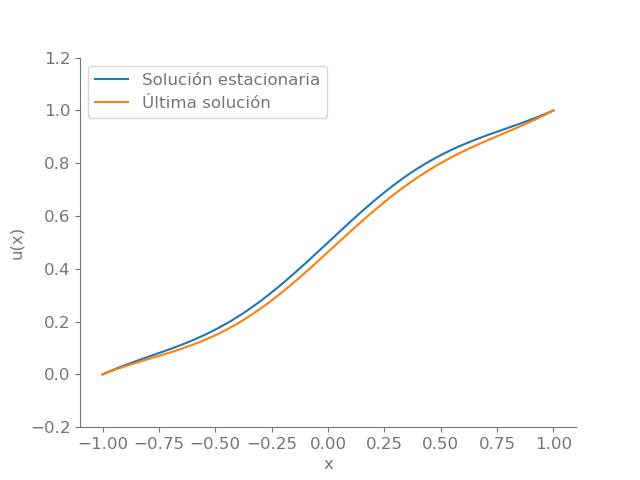

In [7]:
u_estac = u_a*(1 - x)/2 + u_b*(1 + x)/2 - np.sin(4)*x/16 + np.sin(4*x)/16

plt.figure()
plt.plot(x, u_estac)
plt.plot(x, U[-1, :])
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend(["Solución estacionaria", "Última solución"])
plt.ylim(-0.2, 1.2)
plt.show()

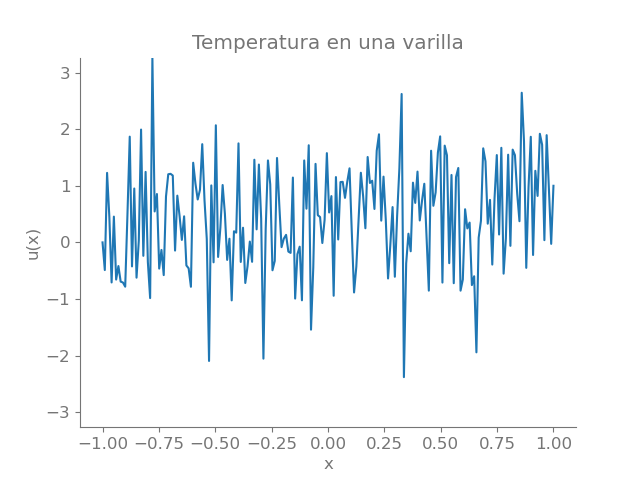

In [8]:
max_val = max(np.max(U), -np.min(U))
fig, ax = plt.subplots()
line, = ax.plot(x, U[0, :])

def update(data):
    line.set_ydata(data)
    plt.ylim(-2, 2)
    return line,

ani = animation.FuncAnimation(fig, update, U, interval=niter//100,
                              repeat=True)

plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Temperatura en una varilla')
plt.ylim(-max_val, max_val)
plt.show()